# **Credit Card Attrition Prediction**

##1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
# Data Visualisation Libraries

from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
# Sythetic Minority Oversampling Technique for handling class imbalance.

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import pickle
#To save and load files

##2. Data Loading and Understanding

In [2]:
# Load dataset to pandas dataframe
dataset = pd.read_csv("BankChurners.csv")

In [3]:
dataset.shape

(10127, 23)

In [4]:
# Print top 5 rows of dataset
dataset.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [6]:
# Dropping irrelevant columns as they are not required for modelling
dataset = dataset.drop(columns=["CLIENTNUM","Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1","Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"])

In [7]:
dataset.head(2)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105


In [8]:
# Printing unique values in all the column to identify them as categorical and numerical
for col in dataset.columns:
  print(col,dataset[col].unique())
  print("-"*50)

Attrition_Flag ['Existing Customer' 'Attrited Customer']
--------------------------------------------------
Customer_Age [45 49 51 40 44 32 37 48 42 65 56 35 57 41 61 47 62 54 59 63 53 58 55 66
 50 38 46 52 39 43 64 68 67 60 73 70 36 34 33 26 31 29 30 28 27]
--------------------------------------------------
Gender ['M' 'F']
--------------------------------------------------
Dependent_count [3 5 4 2 0 1]
--------------------------------------------------
Education_Level ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
--------------------------------------------------
Marital_Status ['Married' 'Single' 'Unknown' 'Divorced']
--------------------------------------------------
Income_Category ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
--------------------------------------------------
Card_Category ['Blue' 'Gold' 'Silver' 'Platinum']
--------------------------------------------------
Months_on_book [39 44 36 3

In [9]:
# For categorical Feature
numerical_features = [
    'Customer_Age',
    'Dependent_count',
    'Months_on_book',
    'Total_Relationship_Count',
    'Months_Inactive_12_mon',
    'Contacts_Count_12_mon',
    'Credit_Limit',
    'Total_Revolving_Bal',
    'Avg_Open_To_Buy',
    'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt',
    'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1',
    'Avg_Utilization_Ratio'
]

for col in dataset.columns:
  if col not in numerical_features:
    print(col,dataset[col].unique())
    print("-"*50)

Attrition_Flag ['Existing Customer' 'Attrited Customer']
--------------------------------------------------
Gender ['M' 'F']
--------------------------------------------------
Education_Level ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
--------------------------------------------------
Marital_Status ['Married' 'Single' 'Unknown' 'Divorced']
--------------------------------------------------
Income_Category ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
--------------------------------------------------
Card_Category ['Blue' 'Gold' 'Silver' 'Platinum']
--------------------------------------------------


In [10]:
# Looking for missing values
dataset.isnull().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


In [11]:
# Check current dtypes
print("Current dtypes:")
print(dataset.dtypes)

# Convert all numerical columns to float for consistency in ML models
numerical_features = [
    'Customer_Age', 'Dependent_count', 'Months_on_book',
    'Total_Relationship_Count', 'Months_Inactive_12_mon',
    'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
    'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
    'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
]

for col in numerical_features:
    dataset[col] = dataset[col].astype(float)

print("\nUpdated dtypes:")
print(dataset.dtypes)

Current dtypes:
Attrition_Flag               object
Customer_Age                  int64
Gender                       object
Dependent_count               int64
Education_Level              object
Marital_Status               object
Income_Category              object
Card_Category                object
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object

Updated dtypes:
Attrition_Flag               object
Customer_Age                float64
Gender                       object
Dependent_count             float64
Education_Level              object
Marital_Status               object
Income_Category  

In [12]:
# Successful Updation Means No missing numerical values

In [13]:
# Checking the class distribution of Target column
print(dataset["Attrition_Flag"].value_counts())

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64


In [14]:
# Clear Imbalance is Visible

**Insights:**

1.   Irrelevant columns(ClientNum , and few others) are removed as they dont require in training the model.
2.   No Missing values in the dataset.
3.   Integer Datatypes are converted to Float safe for the sake of consistency.
4.   Class Imbalance is identified.



##3. Exploratory Data Analysis (EDA)

In [15]:
dataset.shape

(10127, 20)

In [16]:
dataset.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [17]:
# Calculating Descriptive Statistical Aspects
dataset.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


**Numerical Features - Analysis**

In [18]:
# Understanding the distribution of Numerical Features.
def plot_histograms(dataset, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(dataset[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate mean and median for better visualisation
  col_mean = dataset[column_name].mean()
  col_median = dataset[column_name].median()

  # Vertical line for mean and medial
  plt.axvline(col_mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {col_mean:.2f}')
  plt.axvline(col_median, color='green', linestyle='dashed', linewidth=1, label=f'Median: {col_median:.2f}')

  plt.legend()
  plt.show()

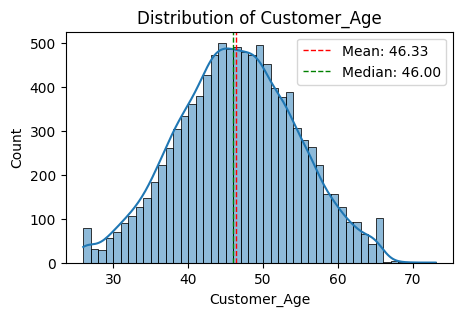

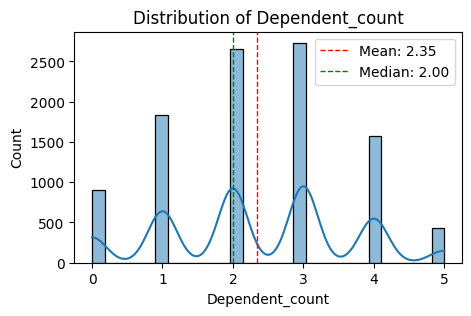

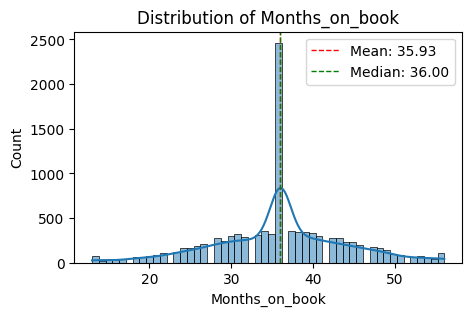

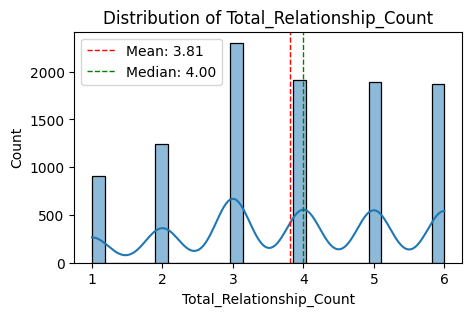

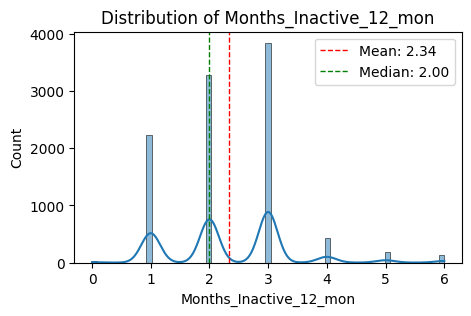

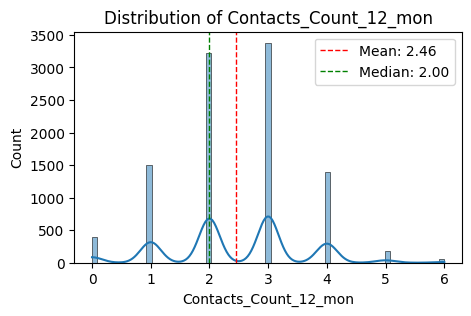

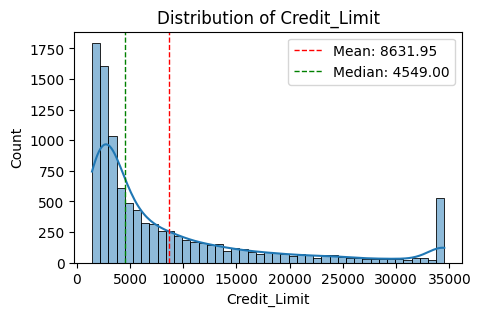

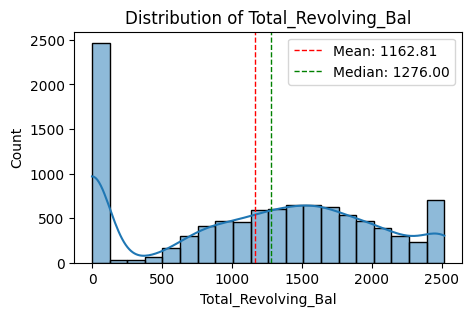

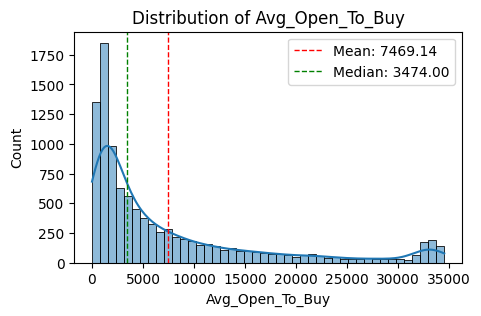

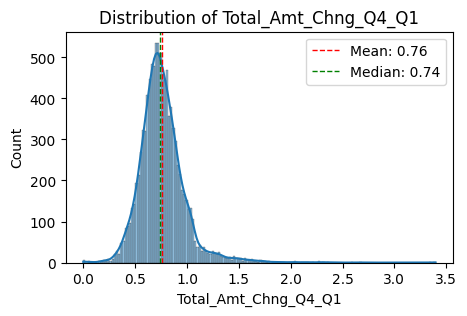

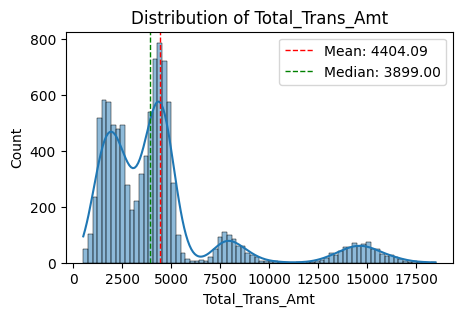

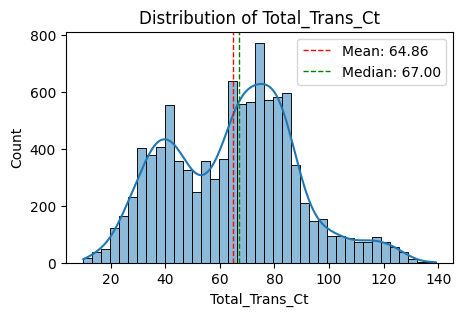

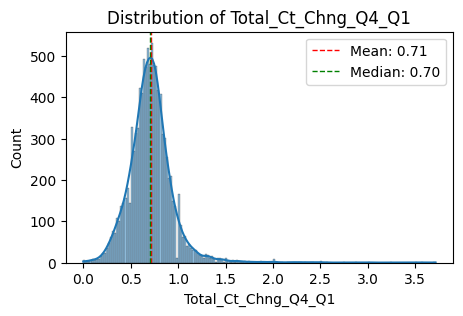

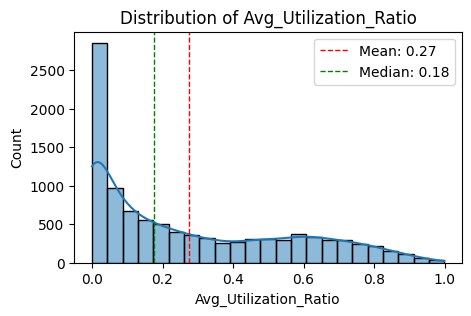

In [19]:
for col in numerical_features:
    plot_histograms(dataset, col)

THE IDEA TO WORK WITH THIS DATA IS THAT YOU CANNOT WORK WITH THIS TYPE OF DATA WHICH IS NOT IN UNIFORM DISTRIBUTION WHEN YOU ARE USING MODEL LIKE LINEAR REG, LOGISTIC REG, SVM. In this condition we'll perform feature scaling (using standard scaler).
BUT Tree based models are not sensitive to distribution.
WE CAN LEAVE THEM AS IT IS.

In [20]:
# Creating Box plots to find Outliers
def plot_boxplots(dataset, column_name):
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=dataset[column_name])
    plt.title(f"Boxplot of {column_name}")

    # Add mean and median lines
    col_mean = dataset[column_name].mean()
    col_median = dataset[column_name].median()

    # Horizontal lines for mean and median
    plt.axhline(col_mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {col_mean:.2f}')
    plt.axhline(col_median, color='green', linestyle='dashed', linewidth=1, label=f'Median: {col_median:.2f}')

    plt.legend()
    plt.show()

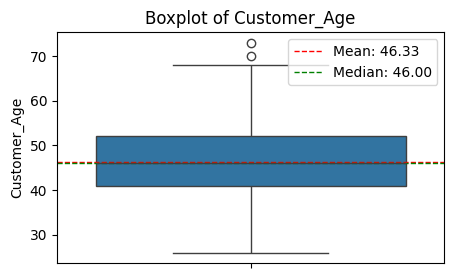

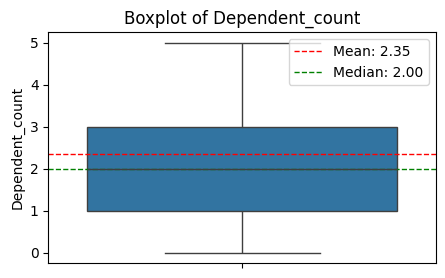

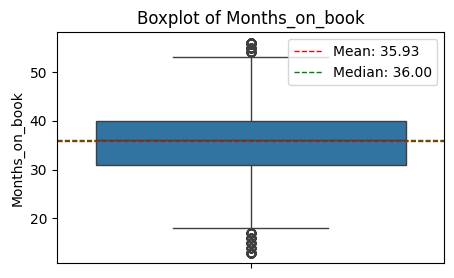

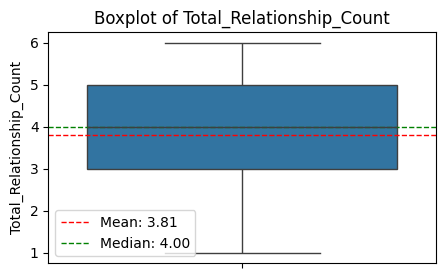

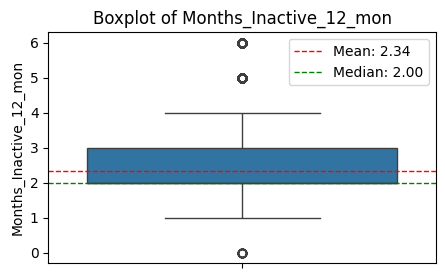

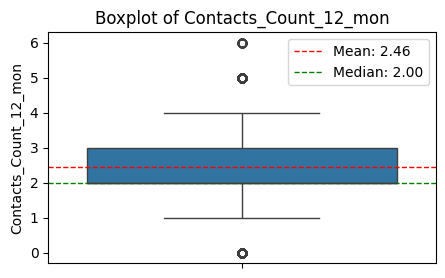

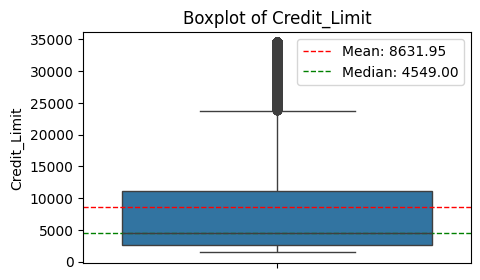

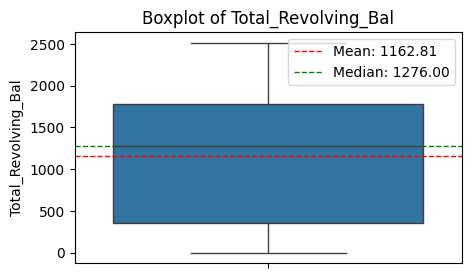

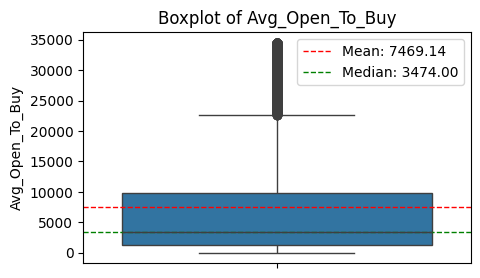

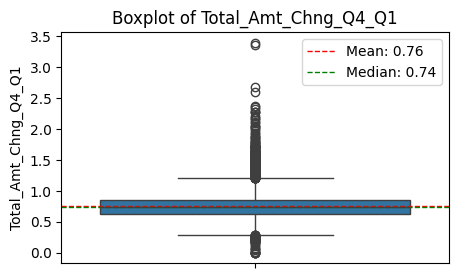

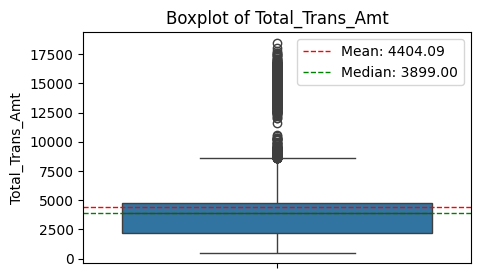

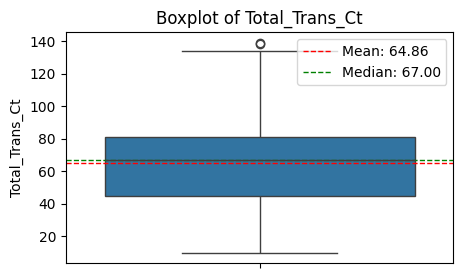

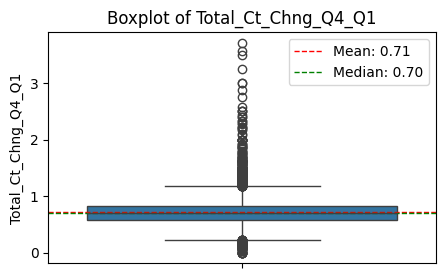

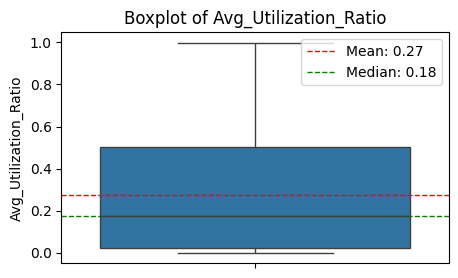

In [21]:
for col in numerical_features:
    plot_boxplots(dataset, col)

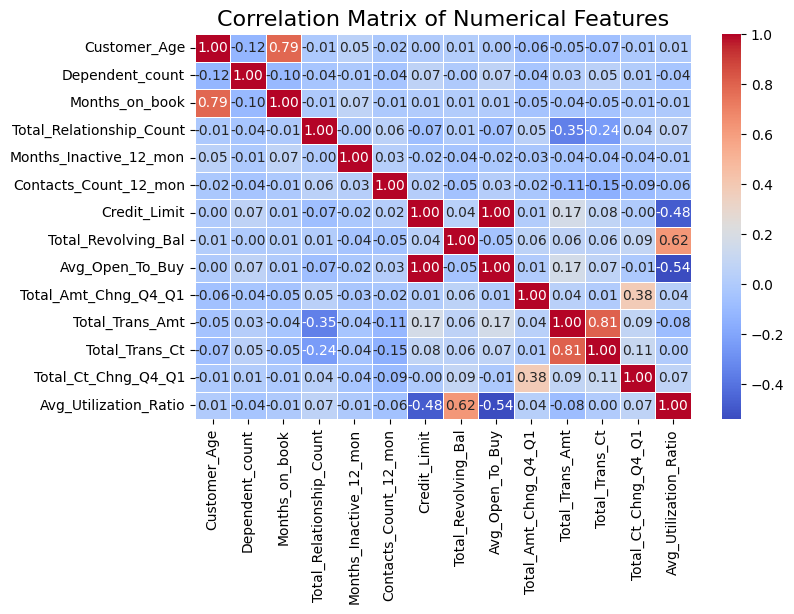

In [22]:
# Correlation Matrix - Heatmap
plt.figure(figsize=(8, 5))
correlation_matrix = dataset[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

There is is strong correlation in following pairs:
Since your models are DT/RF/XGBoost:

1.   Credit_Limit vs Avg_Open_To_Buy = 1.00
2.   Total_Trans_Amt vs Total_Trans_Ct = 0.81
3.   Customer_Age vs Months_on_book = 0.79


Multicollinearity mostly doesn't hurt these models directly but dropping Avg_Open_To_Buy (100% redundant) still makes sense.it reduces noise, avoids wasted split decisions, slightly improves interpretability.

In [23]:
# drop Avg_Open_To_Buy due to redundancy
dataset.drop(columns=['Avg_Open_To_Buy'], inplace=True)

**Categorical Features - Analysis**

In [24]:
dataset.shape

(10127, 19)

In [25]:
dataset.columns

Index(['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count',
       'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [26]:
dataset.info

<bound method DataFrame.info of           Attrition_Flag  Customer_Age Gender  Dependent_count  \
0      Existing Customer          45.0      M              3.0   
1      Existing Customer          49.0      F              5.0   
2      Existing Customer          51.0      M              3.0   
3      Existing Customer          40.0      F              4.0   
4      Existing Customer          40.0      M              3.0   
...                  ...           ...    ...              ...   
10122  Existing Customer          50.0      M              2.0   
10123  Attrited Customer          41.0      M              2.0   
10124  Attrited Customer          44.0      F              1.0   
10125  Attrited Customer          30.0      M              2.0   
10126  Attrited Customer          43.0      F              2.0   

      Education_Level Marital_Status Income_Category Card_Category  \
0         High School        Married     $60K - $80K          Blue   
1            Graduate         Single  Less than $40K          Blue   
2            Graduate        Married    $80K - $120K          Blue   
3         High School        Unknown  Less than $40K          Blue   
4          Uneducated        Married     $60K - $80K          Blue   
...               ...            ...             ...           ...   
10122        Graduate         Single     $40K - $60K          Blue   
10123         Unknown       Divorced     $40K - $60K          Blue   
10124     High School        Married  Less than $40K          Blue   
10125        Graduate        Unknown     $40K - $60K          Blue   
10126        Graduate        Married  Less than $40K        Silver   

       Months_on_book  Total_Relationship_Count  Months_Inactive_12_mon  \
0                39.0                       5.0                     1.0   
1                44.0                       6.0                     1.0   
2                36.0                       4.0                     1.0   
3                34.0                       3.0                     4.0   
4                21.0                       5.0                     1.0   
...               ...                       ...                     ...   
10122            40.0                       3.0                     2.0   
10123            25.0                       4.0                     2.0   
10124            36.0                       5.0                     3.0   
10125            36.0                       4.0                     3.0   
10126            25.0                       6.0                     2.0   

       Contacts_Count_12_mon  Credit_Limit  Total_Revolving_Bal  \
0                        3.0       12691.0                777.0   
1                        2.0        8256.0                864.0   
2                        0.0        3418.0                  0.0   
3                        1.0        3313.0               2517.0   
4                        0.0        4716.0                  0.0   
...                      ...           ...                  ...   
10122                    3.0        4003.0               1851.0   
10123                    3.0        4277.0               2186.0   
10124                    4.0        5409.0                  0.0   
10125                    3.0        5281.0                  0.0   
10126                    4.0       10388.0               1961.0   

       Total_Amt_Chng_Q4_Q1  Total_Trans_Amt  Total_Trans_Ct  \
0                     1.335           1144.0            42.0   
1                     1.541           1291.0            33.0   
2                     2.594           1887.0            20.0   
3                     1.405           1171.0            20.0   
4                     2.175            816.0            28.0   
...                     ...              ...             ...   
10122                 0.703          15476.0           117.0   
10123                 0.804           8764.0            69.0   
10124                 0.819          10291.0        

In [27]:
categorical_features = dataset.select_dtypes(include='object').columns.tolist()
categorical_features

['Attrition_Flag',
 'Gender',
 'Education_Level',
 'Marital_Status',
 'Income_Category',
 'Card_Category']

In [28]:
categorical_features = [
    'Attrition_Flag',      # ['Existing Customer', 'Attrited Customer']
    'Gender',              # ['M', 'F']
    'Education_Level',     # ['High School', 'Graduate', 'Uneducated', 'Unknown', 'College', 'Post-Graduate', 'Doctorate']
    'Marital_Status',      # ['Married', 'Single', 'Unknown', 'Divorced']
    'Income_Category',     # ['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K', '$120K +', 'Unknown']
    'Card_Category'        # ['Blue', 'Gold', 'Silver', 'Platinum']
]

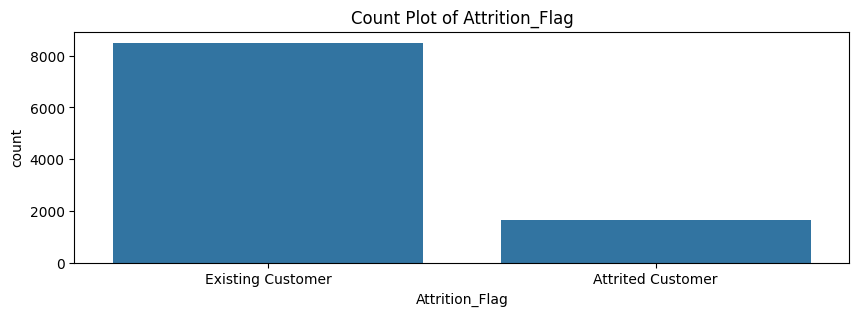

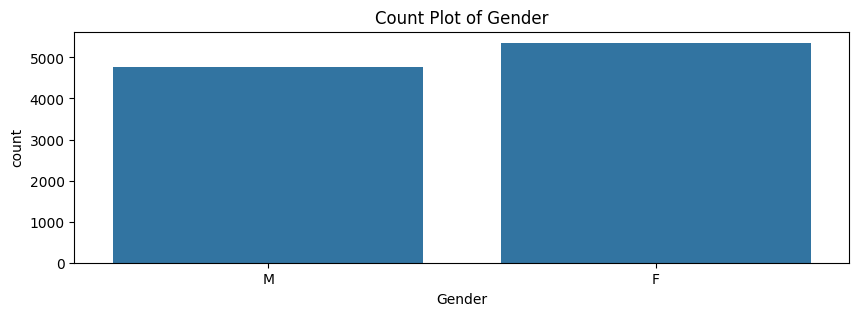

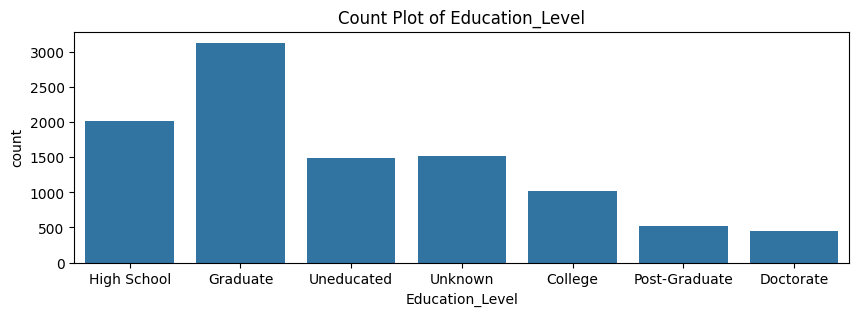

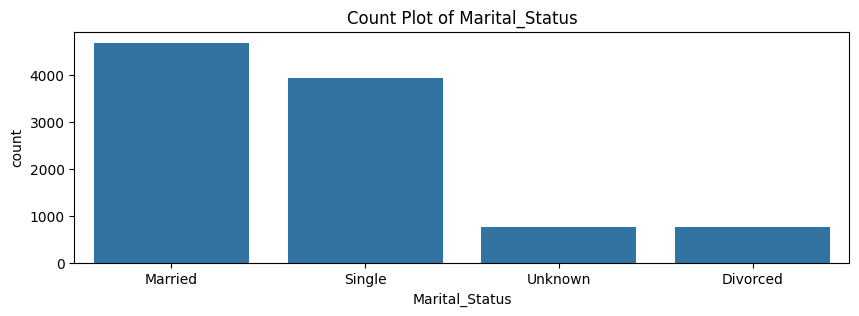

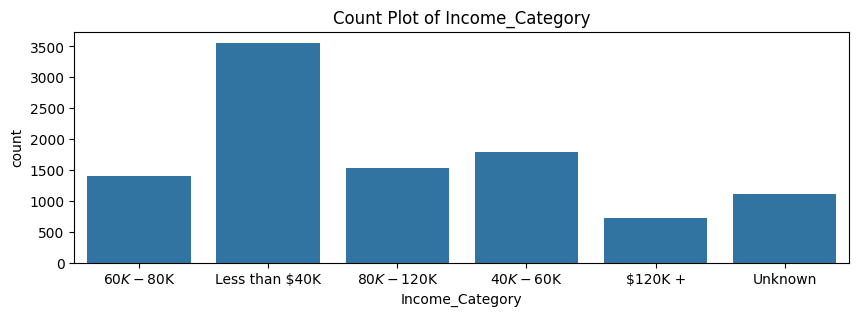

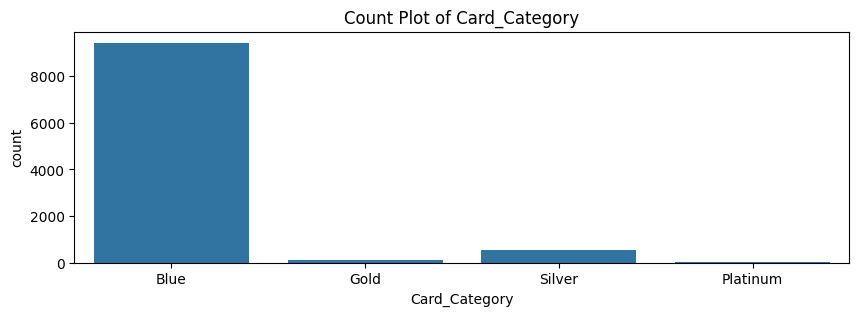

In [29]:
for col in categorical_features:
  plt.figure(figsize=(10, 3))
  sns.countplot(x=col, data=dataset)
  plt.title(f"Count Plot of {col}")
  plt.show()

IMBALANCE IN THE TARGET COLUMN AFFECTS THE MODEL NO MATTER WHAT MODEL WE ARE USING ANY MODEL

##4. Data Preprocessing

In [30]:
dataset.head(3)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45.0,M,3.0,High School,Married,$60K - $80K,Blue,39.0,5.0,1.0,3.0,12691.0,777.0,1.335,1144.0,42.0,1.625,0.061
1,Existing Customer,49.0,F,5.0,Graduate,Single,Less than $40K,Blue,44.0,6.0,1.0,2.0,8256.0,864.0,1.541,1291.0,33.0,3.714,0.105
2,Existing Customer,51.0,M,3.0,Graduate,Married,$80K - $120K,Blue,36.0,4.0,1.0,0.0,3418.0,0.0,2.594,1887.0,20.0,2.333,0.000


In [31]:
# Applying Label Encoder so strings are replaced by numbers
target_le = LabelEncoder()
dataset['Attrition_Flag'] = target_le.fit_transform(dataset['Attrition_Flag'])

feature_cat_cols = ['Gender', 'Marital_Status',]

le_dict = {}
for col in feature_cat_cols:
    le = LabelEncoder()
    dataset[col] = le.fit_transform(dataset[col])
    le_dict[col] = le

income_order = {'Less than $40K':0, '$40K - $60K':1, '$60K - $80K':2, '$80K - $120K':3, '$120K +':4, 'Unknown':-1}
dataset['Income_Category'] = dataset['Income_Category'].map(income_order)

education_order = {'Uneducated':0, 'High School':1, 'College':2, 'Graduate':3, 'Post-Graduate':4, 'Doctorate':5, 'Unknown':-1}
dataset['Education_Level'] = dataset['Education_Level'].map(education_order)

card_order = {'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
dataset['Card_Category'] = dataset['Card_Category'].map(card_order)

In [32]:
# Saving the Encoders in Pickel File
encoders = {
    'target_encoder': target_le,           # LabelEncoder for Attrition_Flag
    'label_encoders': le_dict,             # LabelEncoders for Gender & Marital_Status
    'income_mapping': income_order,        # Mapping for Income_Category
    'education_mapping': education_order,  # Mapping for Education_Level
    'card_mapping': card_order             # Mapping for Card_Category
}

with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(encoders, file)

print("All encoders saved successfully!")
print(f"Saved: {list(encoders.keys())}")


All encoders saved successfully!
Saved: ['target_encoder', 'label_encoders', 'income_mapping', 'education_mapping', 'card_mapping']


In [33]:
encoders
# Saving the encoders cuz when we transform Unkown data we'll need these encoders

{'target_encoder': LabelEncoder(),
 'label_encoders': {'Gender': LabelEncoder(),
  'Marital_Status': LabelEncoder()},
 'income_mapping': {'Less than $40K': 0,
  '$40K - $60K': 1,
  '$60K - $80K': 2,
  '$80K - $120K': 3,
  '$120K +': 4,
  'Unknown': -1},
 'education_mapping': {'Uneducated': 0,
  'High School': 1,
  'College': 2,
  'Graduate': 3,
  'Post-Graduate': 4,
  'Doctorate': 5,
  'Unknown': -1},
 'card_mapping': {'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}}

In [34]:
dataset.head(3)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,1,45.0,1,3.0,1,1,2,0,39.0,5.0,1.0,3.0,12691.0,777.0,1.335,1144.0,42.0,1.625,0.061
1,1,49.0,0,5.0,3,2,0,0,44.0,6.0,1.0,2.0,8256.0,864.0,1.541,1291.0,33.0,3.714,0.105
2,1,51.0,1,3.0,3,1,3,0,36.0,4.0,1.0,0.0,3418.0,0.0,2.594,1887.0,20.0,2.333,0.000


In [35]:
print("Total values in Attrition_Flag:", dataset['Attrition_Flag'].value_counts())

Total values in Attrition_Flag: Attrition_Flag
1    8500
0    1627
Name: count, dtype: int64


In [36]:
print("Unique values in Attrition_Flag:", dataset['Attrition_Flag'].unique())

Unique values in Attrition_Flag: [1 0]


**Train and Test Data Split**

In [37]:
Y = dataset['Attrition_Flag']
X = dataset.drop(columns=['Attrition_Flag'])

In [38]:
print(X)

       Customer_Age  Gender  Dependent_count  Education_Level  Marital_Status  \
0              45.0       1              3.0                1               1   
1              49.0       0              5.0                3               2   
2              51.0       1              3.0                3               1   
3              40.0       0              4.0                1               3   
4              40.0       1              3.0                0               1   
...             ...     ...              ...              ...             ...   
10122          50.0       1              2.0                3               2   
10123          41.0       1              2.0               -1               0   
10124          44.0       0              1.0                1               1   
10125          30.0       1              2.0                3               3   
10126          43.0       0              2.0                3               1   

       Income_Category  Car

In [39]:
print(Y)

0        1
1        1
2        1
3        1
4        1
        ..
10122    1
10123    0
10124    0
10125    0
10126    0
Name: Attrition_Flag, Length: 10127, dtype: int64


In [40]:
# Split Train and Test
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 42)

In [41]:
Y_train.shape

(8101,)

In [42]:
print(Y_train.value_counts())
# Class Imabalance is Clearly Visible

Attrition_Flag
1    6801
0    1300
Name: count, dtype: int64


Synthetic Minority Oversampling Technique

In [43]:
smote = SMOTE(random_state=42)
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)

In [44]:
Y_train.shape

(8101,)

In [45]:
print(Y_train_resampled.value_counts())
# Class is Balanced Now

Attrition_Flag
1    6801
0    6801
Name: count, dtype: int64


Now we'll move towards model training.

##5. Model Training

In [46]:
# Define models and their hyperparameter grids
models_params = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'max_depth': [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'max_features': ['sqrt', 'log2']
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss'),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
    }
}

In [47]:
from sklearn.model_selection import GridSearchCV

cv_scores = {}

for model_name, model_info in models_params.items():
    print(f"Tuning {model_name}...")

    grid_search = GridSearchCV(
        estimator=model_info['model'],
        param_grid=model_info['params'],
        cv=5,
        scoring='f1',          # changed from accuracy
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train_resampled, Y_train_resampled)

    cv_scores[model_name] = {
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'best_model': grid_search.best_estimator_
    }

    print(f"Best {model_name} F1: {grid_search.best_score_:.4f}")
    print(f"Best params: {grid_search.best_params_}\n")

# Pick best model by F1 score
best_model_name = max(cv_scores, key=lambda x: cv_scores[x]['best_score'])
best_model = cv_scores[best_model_name]['best_model']

print(f"Overall Best Model: {best_model_name} with F1 score: {cv_scores[best_model_name]['best_score']:.4f}")

Tuning Decision Tree...
Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Decision Tree F1: 0.9508
Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Tuning Random Forest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Random Forest F1: 0.9754
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}

Tuning XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best XGBoost F1: 0.9718
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}

Overall Best Model: Random Forest with F1 score: 0.9754


##6. Model Evalaution

Best Model: Random Forest

Accuracy Score: 0.9600

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       327
           1       0.97      0.98      0.98      1699

    accuracy                           0.96      2026
   macro avg       0.93      0.92      0.93      2026
weighted avg       0.96      0.96      0.96      2026



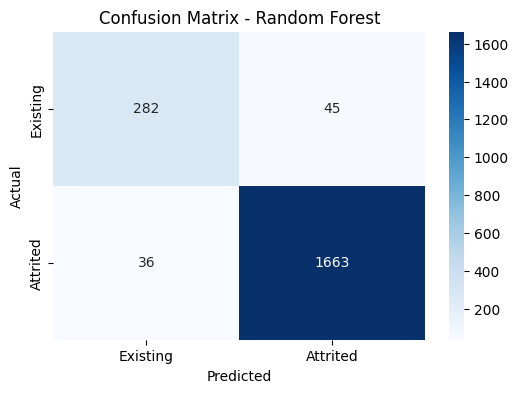

In [48]:
# Evaluating Best Model On Test Data
best_model_name = max(cv_scores, key=lambda x: cv_scores[x]['best_score'])
best_model = cv_scores[best_model_name]['best_model']

print(f"Best Model: {best_model_name}\n")

# Predict on test data
Y_pred = best_model.predict(X_test)

# Accuracy Score
acc = accuracy_score(Y_test, Y_pred)
print(f"Accuracy Score: {acc:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

In [49]:
# save the trained model to pickel file.
model_data = {
    'model': best_model,
    'feature_names': X.columns.tolist()
}

with open('Credit_Card_Customer_Attrition_Model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

##7. Loading the saved Models and Building Predictive System

In [50]:
# Load the saved Model and encoders
with open('label_encoders.pkl', 'rb') as file:
    encoders = pickle.load(file)
with open('Credit_Card_Customer_Attrition_Model.pkl', 'rb') as file:
    model = pickle.load(file)

loaded_model = model_data['model']
loaded_feature_names = model_data['feature_names']
loaded_encoders = encoders

In [51]:
print(loaded_model)

RandomForestClassifier(n_estimators=300, random_state=42)


In [52]:
print(loaded_feature_names)

['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [53]:
print(loaded_encoders)

{'target_encoder': LabelEncoder(), 'label_encoders': {'Gender': LabelEncoder(), 'Marital_Status': LabelEncoder()}, 'income_mapping': {'Less than $40K': 0, '$40K - $60K': 1, '$60K - $80K': 2, '$80K - $120K': 3, '$120K +': 4, 'Unknown': -1}, 'education_mapping': {'Uneducated': 0, 'High School': 1, 'College': 2, 'Graduate': 3, 'Post-Graduate': 4, 'Doctorate': 5, 'Unknown': -1}, 'card_mapping': {'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}}


In [60]:
input_data = {
    'Customer_Age': [57],
    'Gender': ['F'],
    'Dependent_count': [2],
    'Education_Level': ['Graduate'],
    'Marital_Status': ['Married'],
    'Income_Category': ['Less than $40K'],
    'Card_Category': ['Blue'],
    'Months_on_book': [48],
    'Total_Relationship_Count': [5],
    'Months_Inactive_12_mon': [2],
    'Contacts_Count_12_mon': [2],
    'Credit_Limit': [2436.0],
    'Total_Revolving_Bal': [680.0],
    'Total_Amt_Chng_Q4_Q1': [1.19],
    'Total_Trans_Amt': [1756.0],
    'Total_Trans_Ct': [60.0],
    'Total_Ct_Chng_Q4_Q1': [0.8],
    'Avg_Utilization_Ratio': [0.611]
}

input_data_dataframe = pd.DataFrame(input_data)

In [61]:
# encoding categorical feature with the saved encoders

# Apply LabelEncoders (Gender, Marital_Status)
for column, encoder in loaded_encoders['label_encoders'].items():
    input_data_dataframe[column] = encoder.transform(input_data_dataframe[column])

In [62]:
# Apply manual ordinal mappings
input_data_dataframe['Income_Category'] = input_data_dataframe['Income_Category'].map(loaded_encoders['income_mapping'])
input_data_dataframe['Education_Level'] = input_data_dataframe['Education_Level'].map(loaded_encoders['education_mapping'])
input_data_dataframe['Card_Category'] = input_data_dataframe['Card_Category'].map(loaded_encoders['card_mapping'])

In [63]:
print(input_data_dataframe.head())

   Customer_Age  Gender  Dependent_count  Education_Level  Marital_Status  \
0            57       0                2                3               1   

   Income_Category  Card_Category  Months_on_book  Total_Relationship_Count  \
0                0              0              48                         5   

   Months_Inactive_12_mon  Contacts_Count_12_mon  Credit_Limit  \
0                       2                      2        2436.0   

   Total_Revolving_Bal  Total_Amt_Chng_Q4_Q1  Total_Trans_Amt  Total_Trans_Ct  \
0                680.0                  1.19           1756.0            60.0   

   Total_Ct_Chng_Q4_Q1  Avg_Utilization_Ratio  
0                  0.8                  0.611  


In [64]:
# Reorder columns to match training feature order
input_data_dataframe = input_data_dataframe[loaded_feature_names]

In [65]:
# Predict
prediction = loaded_model.predict(input_data_dataframe)
print(prediction)

[1]


In [66]:
# Decoding prediction back to label
predicted_label = loaded_encoders['target_encoder'].inverse_transform(prediction)
print(predicted_label)

['Existing Customer']


In [67]:
# Predicting probabilty
predicted_probabilities = loaded_model.predict_proba(input_data_dataframe)
print(predicted_probabilities)

[[0.03333333 0.96666667]]
